<h1> Histplot </h1>

목적

데이터 분포의 모양(꼬리, 중앙집중, 분산 등)과 빈도 구조를 직관적 파악하여 모델링 전처리 의사결정시 참고합니다.

1. 전처리·변환(로그·스케일링·인코딩) 전략
2. 모델·검정 가정(정규성·등분산·분포 family)
3. 이상치·결측치 처리
4. 샘플링·가중치 조정 를 합리적으로 설계

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
# 예시 DataFrame
df = pd.DataFrame({
    'A': [0.1, 0.5, 0.3, 0.7, 0.2],
    'B': [1, 10, 50, 100, 500],
    'C': [0.01, 0.02, 0.015, 0.03, 0.025]
})

,A,B,C
0,0.1,1,0.010
1,0.5,10,0.020
2,0.3,50,0.015
3,0.7,100,0.030
4,0.2,500,0.025


In [12]:
df

,A,B,C
0,0.1,1,0.010
1,0.5,10,0.020
2,0.3,50,0.015
3,0.7,100,0.030
4,0.2,500,0.025


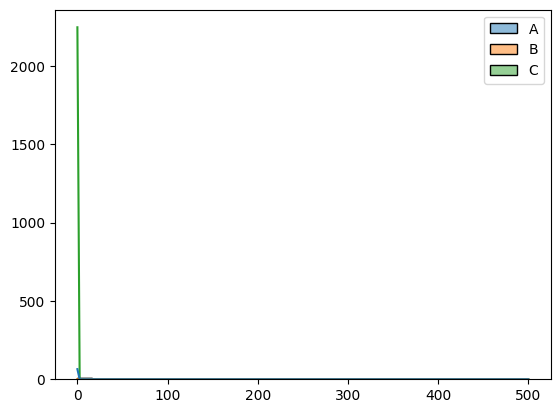

In [8]:
plt.figure()
sns.histplot(df, bins = 30, kde = True)
plt.xlabel('')
plt.ylabel('')
plt.show()

In [9]:
# 1) skewness 계산
skews = df.skew()
print("Skewness:\n", skews)

Skewness:
 A    0.601364
B    2.048926
C    0.000000
dtype: float64


In [10]:
# 2) range 계산
ranges = df.max() - df.min()
print("\nRange:\n", ranges)


Range:
 A      0.60
B    499.00
C      0.02
dtype: float64


In [13]:
# 3) 판단
for col in df.columns:
    s = skews[col]
    r = ranges[col]
    skew_lvl = ("대칭" if abs(s)<0.5 else
                "중등도 치우침" if abs(s)<1 else
                "심한 치우침")
    print(f"{col}: skew={s:.2f} → {skew_lvl}, range={r:.3f}")


A: skew=0.60 → 중등도 치우침, range=0.600
B: skew=2.05 → 심한 치우침, range=499.000
C: skew=0.00 → 대칭, range=0.020


<h1> 치우침(skewness)의 기준 </h1>

|skewness| < 0.5 : 거의 대칭 , 
0.5 ≤ |skewness| < 1.0 : 중등도 치우침 , 
|skewness| ≥ 1.0 : 심한 치우침

<h1> 스케일 차이(range)의 기준 </h1>

서로 다른 피처들(column) 의 range(max–min) 비율이 10배 이상 차이날 때 또는 하나의 피처 range가 다른 피처 range들의 평균보다 10배 이상 클 때

<h1> 대처법 </h1>

|skewness| ≥ 1.0 일때, 로그 변환(np.log1p), Box–Cox, Yeo–Johnson 등 적용

range 비율 ≥ 10 일때, StandardScaler(z‑score) 또는 MinMaxScaler로 통일